<a href="https://colab.research.google.com/github/NataliiaFakas/TFG_BMW/blob/main/4_Selecci%C3%B3n_Variables_y_repetir_RandomForests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Repetir estudio con Random Forest utilizando las variables seleccionadas

---

## Selección de variables macroeconómicas

Tras analizar la importancia de las variables mediante el modelo Random Forest, se ha decidido conservar únicamente aquellas variables que presentan una mayor capacidad explicativa sobre las ventas de vehículos BMW en Europa.

Las variables seleccionadas son las siguientes:

| Variable | Importancia |
|-----------|-----------:|
| Compensation_Per_Employee | 0.289217 |
| Industrial_Production | 0.281089 |
| Population_Total | 0.227091 |
| EUR_USD | 0.108843 |

Estas variables representan aproximadamente el **90,6 % de la importancia total** obtenida en el modelo, por lo que pueden considerarse las variables macroeconómicas más relevantes para explicar la evolución histórica de las ventas de BMW en Europa.

La elevada concentración de importancia en este reducido conjunto de variables sugiere que factores relacionados con el poder adquisitivo de los consumidores, la actividad económica industrial, el tamaño potencial del mercado y las condiciones macroeconómicas internacionales desempeñan un papel fundamental en la determinación de las ventas de la compañía.

A continuación, se repetirá el análisis utilizando exclusivamente estas cuatro variables con el objetivo de estudiar cómo se redistribuye el **9,4 % de importancia correspondiente a las variables eliminadas** entre las variables seleccionadas y comprobar la estabilidad de los resultados obtenidos en el modelo inicial.

---

# 1. Carga de datasets

In [1]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

ruta_macro = "/content/drive/MyDrive/TFG_BMW/datasets/bmw_dataset_variables_macro.csv"
ruta_bmw = "/content/drive/MyDrive/TFG_BMW/datasets/ventas_bmw.csv"

df_macro = pd.read_csv(ruta_macro)
df_bmw = pd.read_csv(ruta_bmw)

display(df_macro.head())
display(df_bmw.head())

Mounted at /content/drive


,Year,Unemployment_Rate,GDP_Growth,Deposit_Facility,HICP,Industrial_Production,Retail_Sales_Growth,Consumer_Confidence,Compensation_Per_Employee,Brent_Oil_Price,EUR_USD,Euribor_12M,Population_Total
0,2005,8.9,1.7,1.25,2.18,153.2,0.03,-4.2,31.22,54.57,1.2441,2.19,434585887
1,2006,8.2,3.2,2.50,2.19,147.7,0.04,-3.5,31.95,65.16,1.2556,3.08,436041018
2,2007,7.2,2.9,3.00,2.13,145.5,0.03,-2.1,32.75,72.44,1.3705,4.24,437514477
3,2008,7.1,0.4,2.00,3.30,148.0,0.01,-10.8,33.86,96.94,1.4708,4.63,439074280
4,2009,9.0,-4.4,0.25,0.29,144.5,-0.03,-21.7,34.41,61.74,1.3948,1.31,440467898


,Año,Ventas_BMW_Unidades
0,2005,1126768
1,2006,1185088
2,2007,1276793
3,2008,1202239
4,2009,1068770



---


## 2. Selección de variables macroeconómicas

A partir de los resultados obtenidos en el análisis de importancia de variables mediante Random Forest, se han seleccionado las cuatro variables con mayor capacidad explicativa sobre las ventas de BMW en Europa:

- Compensation_Per_Employee
- Industrial_Production
- Population_Total
- EUR_USD

Estas variables concentran aproximadamente el 90,6 % de la importancia total obtenida en el modelo inicial, por lo que se utilizarán para construir una versión reducida del modelo y analizar c


---



In [2]:
variables_modelo = [
    "Year",
    "Compensation_Per_Employee",
    "Industrial_Production",
    "Population_Total",
    "EUR_USD"
]

df_macro_reducido = df_macro[variables_modelo]

df_macro_reducido.head()

,Year,Compensation_Per_Employee,Industrial_Production,Population_Total,EUR_USD
0,2005,31.22,153.2,434585887,1.2441
1,2006,31.95,147.7,436041018,1.2556
2,2007,32.75,145.5,437514477,1.3705
3,2008,33.86,148.0,439074280,1.4708
4,2009,34.41,144.5,440467898,1.3948




---


# 3. Función para añadir variables macroeconómicas


---

🔧 **Reutilizaremos esta función cada vez que se entrene un nuevo modelo** para incorporar al conjunto de datos de ventas de BMW, las variables macroeconómicas seleccionadas utilizando el año como clave de unión.

In [3]:
def añadir_variables_macro(df_bmw, df_macro):

    df_final = df_bmw.merge(
        df_macro[variables_modelo],
        on="Year",
        how="left"
    )

    return df_final



---

# 4. Construcción de matrices X e y y entrenamiento del modelo RandomForest

---

In [4]:
data = pd.merge(
    df_bmw,
    df_macro_reducido,
    left_on="Año",
    right_on="Year"
)
data = data.drop(columns=["Year"])

X = data.drop(columns=["Año", "Ventas_BMW_Unidades"])
y = data["Ventas_BMW_Unidades"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (21, 4)
y shape: (21,)


In [5]:
from sklearn.ensemble import RandomForestRegressor

modelo_reducido = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo_reducido.fit(X, y)

importancias_reducido = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_reducido.feature_importances_
}).sort_values(by="Importancia", ascending=False)

print(importancias_reducido)

                    Variable  Importancia
0  Compensation_Per_Employee     0.339008
1      Industrial_Production     0.303397
2           Population_Total     0.278002
3                    EUR_USD     0.079592


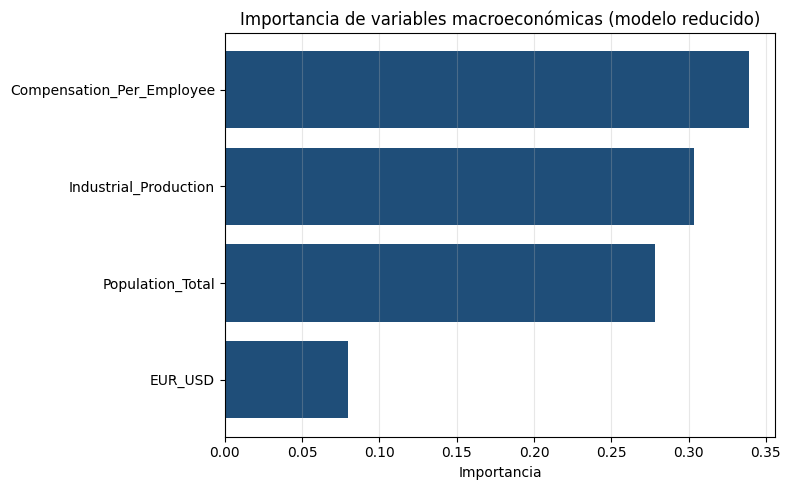

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.barh(importancias_reducido["Variable"], importancias_reducido["Importancia"], color="#1F4E79")
plt.gca().invert_yaxis()
plt.title("Importancia de variables macroeconómicas (modelo reducido)")
plt.xlabel("Importancia")
plt.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## 5. Comparación con el modelo completo (12 variables)

| Variable | Importancia (modelo completo) | Importancia (modelo reducido) | Diferencia |
|-----------|-------------------------------:|-------------------------------:|-----------:|
| `Compensation_Per_Employee` | 0,2892 | 0,3390 | +0,0498 |
| `Industrial_Production` | 0,2811 | 0,3034 | +0,0223 |
| `Population_Total` | 0,2271 | 0,2780 | +0,0509 |
| `EUR_USD` | 0,1088 | 0,0796 | -0,0292 |
| **Suma** | **0,9062** | **1,0000** | **+0,0938** |

Al eliminar las ocho variables menos relevantes del modelo original, el 9,38 % de
importancia que éstas concentraban en el modelo completo (coincidente con el 9,4 %
señalado inicialmente) se redistribuye entre las cuatro variables seleccionadas, si
bien de forma desigual.

---

### Jerarquía de variables: se mantiene estable

El orden de importancia relativa entre las cuatro variables no varía entre ambos
modelos. Por lo que esta
estabilidad en el ránking refuerza la fiabilidad de estas variables como los
predictores macroeconómicos más consistentes para explicar las ventas de BMW,
independientemente del número total de variables incluidas en el modelo.

---

### Redistribución desigual: el caso de `EUR_USD`

El resultado más destacable de esta comparación es que `EUR_USD` es la única de las
cuatro variables que pierde importancia en términos absolutos al reducir el conjunto
de predictores (de 0,1088 a 0,0796), a pesar de que el modelo reducido, al tener menos
variables, redistribuye entre todas ellas el peso de las variables eliminadas.

Esto sugiere que gran parte de la información que aportaban las ocho variables
eliminadas (especialmente aquellas con las que `EUR_USD` mostraba mayor correlación
en el análisis de VIF, como `Industrial_Production`) resultaba en cierta medida
redundante con `Compensation_Per_Employee` y `Population_Total`, más que con
`EUR_USD`.

Al eliminar dichas variables, el modelo tiende a concentrar aún más su capacidad explicativa en las dos variables con tendencias estructurales más marcadas
(`Compensation_Per_Employee` y `Population_Total`, ambas con una tendencia creciente
muy sostenida), en detrimento relativo de `EUR_USD`.

---

### Cautela interpretativa

Como ya se ha señalado en apartados anteriores, estos resultados deben tomarse con
prudencia dado el reducido tamaño muestral (21 observaciones) y el elevado grado de
multicolinealidad detectado entre estas mismas cuatro variables en el análisis de VIF
(especialmente entre `Population_Total` y `Compensation_Per_Employee`, con una
correlación de 0,96). La estabilidad del ranking es una señal positiva de robustez,
pero la magnitud exacta de la importancia de cada variable puede verse afectada por
esta redundancia informativa entre predictores.